# Data and Vocabulary Preparation

In [1]:
# Download and decompress text8
# !wget http://mattmahoney.net/dc/text8.zip -O text8.gz
# !gzip -d text8.gz -f

In [2]:
from collections import Counter

# Load and preprocess the corpus
with open("text8", "r") as f:
    text = f.read().lower()
    tokens = text.split()
    
min_freq = 5
word_freq = Counter(tokens) # gets the freq of all unique words
vocab = [(w, c) for w, c in word_freq.items() if c >= min_freq]

vocab.sort(key=lambda x : (-x[1], x[0]))

# Add <UNK> to the vocab. Its frequency is the sum of all rare words.
unk_count = sum(c for w, c in word_freq.items() if c < min_freq)
vocab.append(('<UNK>', unk_count))

vocab_size = len(vocab)

In [3]:
word_to_idx = {w: i for i, (w,_) in enumerate(vocab)}
idx_to_word = {i: w for i, (w,_) in enumerate(vocab)}

In [4]:
print(f"Original token count: {len(tokens):,}")
print(f"Filtered vocabulary size: {len(vocab):,}")

Original token count: 17,005,207
Filtered vocabulary size: 71,291


In [ ]:
unk_idx = word_to_idx['<UNK>']
train_data = []

for token in tokens:
    # Get the ID. If it's not in our filtered vocab, use <UNK>
    token_id = word_to_idx.get(token, unk_idx)
    train_data.append(token_id)

print(f"Full corpus ID list created. Length: {len(train_data):,}")

Full corpus ID list created. Length: 17,005,207


# SkipGram Training Pair Generation

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import random

class SkipGramDataset(Dataset):
    """
    A PyTorch Dataset for generating skip-gram (center_word, context_word) pairs.
    """
    def __init__(self, token_ids, window_size):
        """
        Args:
            token_ids (list[int]): The list of token IDs.
            window_size (int): The maximum window size.
        """
        self.token_ids   = token_ids
        self.window_size = window_size
        
        # This will store all our (center, context) training pairs
        self.pairs = []
        
        print("Generating training pairs...")
        self._generate_pairs()
        print(f"Generated {len(self.pairs):,} training pairs.")
        
    def _generate_pairs(self):
        """
        Generates all (center, context) pairs and stores them in self.pairs.
        """
        num_tokens = len(self.token_ids)
        
        # Iterate over each token in the corpus to be a center word
        for center_word_idx in range(num_tokens):
            center_word_id = self.token_ids[center_word_idx]
            # Pick a random window size
            current_window_size = random.randint(1, self.window_size)
            
            start_idx = max(0, center_word_idx - current_window_size)
            end_idx   = min(num_tokens, center_word_idx + current_window_size + 1)
            
            for context_word_idx in range(start_idx, end_idx):
                if center_word_idx == context_word_idx:
                    continue
                context_word_id = self.token_ids[context_word_idx]
                self.pairs.append((center_word_id, context_word_id))
    
    def __len__(self):
        """Returns the total number of training pairs."""
        return len(self.pairs)
    
    def __getitem__(self, idx):
        """
        Returns a single (center_word, context_word) pair using tensor.
        """
        center_id, context_id = self.pairs[idx]
        
        # Return as tensors
        return (
            torch.tensor(center_id, dtype=torch.long), 
            torch.tensor(context_id, dtype=torch.long)
        )

In [ ]:
window_size = 5
batch_size  = 1024

test_token_ids = train_data[:100000]
skipgram_dataset = SkipGramDataset(test_token_ids, window_size)

dataloader = DataLoader(
    skipgram_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=2 
)

print("\n--- Testing the DataLoader ---")
center_batch, context_batch = next(iter(dataloader))

print(f"Center batch shape:  {center_batch.shape}")
print(f"Context batch shape: {context_batch.shape}")

print("\nExample center IDs:")
print(center_batch[:5])

print("\nExample context IDs:")
print(context_batch[:5])

Generating training pairs...
Generated 599,502 training pairs.

--- Testing the DataLoader ---
Center batch shape:  torch.Size([1024])
Context batch shape: torch.Size([1024])

Example center IDs:
tensor([5337,  678, 5330, 4799,    0])

Example context IDs:
tensor([   0, 3941, 4632,  224,   10])


# Naive SkipGram Model(Full Softmax)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F

n_embd = 300

class SkipGramModel(nn.Module):
    """
    Implements the Naive Skip-Gram model with Full Softmax.
    """
    def __init__(self):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_embd = n_embd
        
        self.input_embeddings  = nn.Embedding(vocab_size, n_embd)  # Center/input word embeddings (vocab_size, n_embd)
        self.output_embeddings = nn.Embedding(vocab_size, n_embd)  # Context/output word embeddings (vocab_size, n_embd)
        
        self.input_embeddings.weight.data.uniform_(-0.5 , 0.5)
        self.output_embeddings.weight.data.uniform_(-0.5 , 0.5)
        
    def forward(self, center_words, context_words=None):
        """
        Forward pass to get the center embeddings.
        center_words: tensor of shape (batch_size,)
        """
        center_embeds = self.input_embeddings(center_words) # (batch_size, n_embd)
        logits = center_embeds @ self.output_embeddings.weight.T # (batch_size, n_embd) @ (vocab_size, n_embd).T ---> (batch_size, vocab_size)
        loss = None
        if context_words is not None:
            loss = F.cross_entropy(logits, context_words) # does softmax first then cross entropy
        return logits, loss

In [9]:
lr = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

model = SkipGramModel()
m = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr)

cuda



Starting Epoch 1/3
Epoch 1, Batch 100/586, Loss: 11.6040, Grad Norm: 0.2340
Epoch 1, Batch 200/586, Loss: 10.4456, Grad Norm: 0.2395
Epoch 1, Batch 300/586, Loss: 9.4140, Grad Norm: 0.2343
Epoch 1, Batch 400/586, Loss: 8.6779, Grad Norm: 0.2287
Epoch 1, Batch 500/586, Loss: 8.1871, Grad Norm: 0.2216
Completed Epoch 1/3

Starting Epoch 2/3
Epoch 2, Batch 100/586, Loss: 14.1657, Grad Norm: 0.2166
Epoch 2, Batch 200/586, Loss: 7.2742, Grad Norm: 0.2158
Epoch 2, Batch 300/586, Loss: 7.1589, Grad Norm: 0.2145
Epoch 2, Batch 400/586, Loss: 7.0765, Grad Norm: 0.2103
Epoch 2, Batch 500/586, Loss: 7.0039, Grad Norm: 0.2078
Completed Epoch 2/3

Starting Epoch 3/3
Epoch 3, Batch 100/586, Loss: 12.6726, Grad Norm: 0.2063
Epoch 3, Batch 200/586, Loss: 6.6480, Grad Norm: 0.2135
Epoch 3, Batch 300/586, Loss: 6.6372, Grad Norm: 0.2054
Epoch 3, Batch 400/586, Loss: 6.6433, Grad Norm: 0.2094
Epoch 3, Batch 500/586, Loss: 6.6166, Grad Norm: 0.2067
Completed Epoch 3/3

Training Complete!
Total batches pr

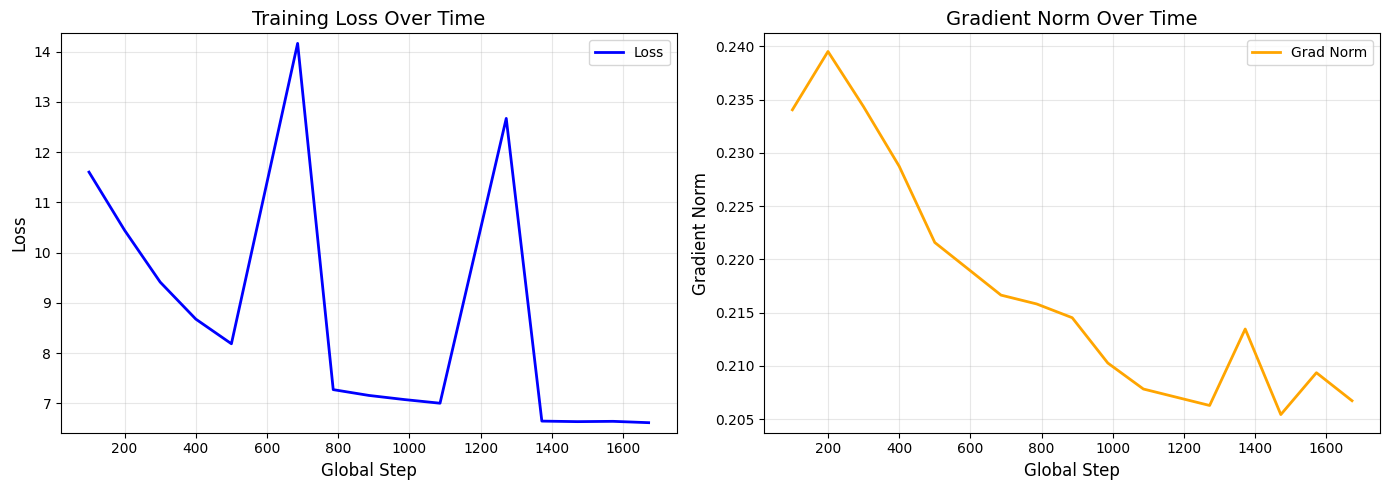

: 

In [ ]:
import matplotlib.pyplot as plt

num_epochs  = 3  
print_every = 100  

running_loss = 0.0
losses = []
grad_norms = []
steps = []
global_step = 0

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Starting Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")
    
    for i, (center_ids, context_ids) in enumerate(dataloader):
        center_ids = center_ids.to(device)
        context_ids = context_ids.to(device)
        
        logits, loss = model(center_ids, context_ids)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        global_step += 1
        
        # Log metrics every print_every steps
        if (i + 1) % print_every == 0:
            # Compute gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            total_norm = total_norm ** 0.5
            
            avg_loss = running_loss / print_every
            losses.append(avg_loss)
            grad_norms.append(total_norm)
            steps.append(global_step)
            
            print(f"Epoch {epoch+1}, Batch {i+1}/{len(dataloader)}, "
                  f"Loss: {avg_loss:.4f}, Grad Norm: {total_norm:.4f}")
            
            running_loss = 0.0
    
    print(f"Completed Epoch {epoch+1}/{num_epochs}")

print("\nTraining Complete!")
print(f"Total batches processed: {global_step}")

# --- Plotting ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(steps, losses, label="Loss", color='blue', linewidth=2)
plt.xlabel("Global Step", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Loss Over Time", fontsize=14)
plt.ylim([min(losses) - 0.2, max(losses) + 0.2])
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(steps, grad_norms, label="Grad Norm", color='orange', linewidth=2)
plt.xlabel("Global Step", fontsize=12)
plt.ylabel("Gradient Norm", fontsize=12)
plt.title("Gradient Norm Over Time", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, n_embd):
        super().__init__()
        self.input_embeddings = nn.Embedding(vocab_size, n_embd)
        self.output_embeddings = nn.Embedding(vocab_size, n_embd)

    def forward(self, center_words, context_words=None):
        center_embeds = self.input_embeddings(center_words)
        logits = center_embeds @ self.output_embeddings.weight.T
        loss = None
        if context_words is not None:
            loss = F.cross_entropy(logits, context_words)
        return logits, loss


# Hierarchical Softmax

## Huffman Tree Construction

In [2]:
# Node Structures

class LeafNode:
    """A leaf node in the Huffman tree, representing a word."""
    def __init__(self, word_id, freq):
        self.word_id = word_id
        self.freq    = freq
        
    def __repr__(self):
        return f"Leaf(id={self.word_id}, f={self.freq})"

class InternalNode:
    """An internal node in the Huffman tree, representing a path choice."""
    def __init__(self, internal_id, freq, left, right):
        # This ID is the index into the 'out_embed' (syn1) matrix
        self.internal_id = internal_id
        self.freq = freq
        self.left = left
        self.right = right
    
    def __repr__(self):
        return f"Internal(id={self.internal_id}, f={self.freq})"
        

In [3]:
import heapq
from itertools import count

def build_huffman_tree(id_to_freq: dict) -> InternalNode:
    
    heap = []
    tie_breaker = count() # Ensures heap items are unique and comparable
    vocab_size = len(id_to_freq)
    
    print(f"Building tree for {vocab_size} words...")
    for word_id, freq in id_to_freq.items():
        node = LeafNode(word_id=word_id, freq=freq)
        heapq.heappush(heap, (freq, next(tie_breaker), node))

    internal_node_counter = 0
    while len(heap) > 1:
        freq_left, _, node_left   = heapq.heappop(heap)
        freq_right, _, node_right = heapq.heappop(heap)

        new_freq = freq_left + freq_right

        new_node = InternalNode(
            internal_id=internal_node_counter,
            freq=new_freq,
            left=node_left,
            right=node_right
        )
        
        heapq.heappush(heap, (new_freq, next(tie_breaker), new_node))
        internal_node_counter += 1

    print(f"Tree built. Total internal nodes: {internal_node_counter}")
    if internal_node_counter != vocab_size - 1:
        print(f"Warning: Expected {vocab_size - 1} internal nodes, but got {internal_node_counter}")

    _root_freq, _tie_break, root_node = heap[0]
    return root_node

In [4]:
vocab_freqs = {
    0: 45, 
    1: 16, 
    2: 13, 
    3: 12, 
    4: 9,  
    5: 5,  
}

root = build_huffman_tree(vocab_freqs)

print("\n--- Tree Structure Example ---")
print(f"Root Node: {root}")
print(f"Root Freq: {root.freq}") # Should be 100

print(f"Root's Left Child: {root.left}")  # Should be Internal(id=3, f=55)
print(f"Root's Right Child: {root.right}") # Should be Leaf(id=0, f=45)

print(f"Root->Right->Left: {root.right.left}") # Should be Internal(id=1, f=25)
print(f"Root->Right->Right: {root.right.right}") # Should be Internal(id=2, f=30)

Building tree for 6 words...
Tree built. Total internal nodes: 5

--- Tree Structure Example ---
Root Node: Internal(id=4, f=100)
Root Freq: 100
Root's Left Child: Leaf(id=0, f=45)
Root's Right Child: Internal(id=3, f=55)
Root->Right->Left: Internal(id=1, f=25)
Root->Right->Right: Internal(id=2, f=30)


## Generate Path Lookups

In [5]:
def generate_path_lookups(root_node: InternalNode) -> dict:
    word_lookups = {}
    
    curr_path_idxs = []
    curr_path_codes = []
    
    def dfs(node):
        # base case
        if isinstance(node, LeafNode):
            word_lookups[node.word_id] = (
                list(curr_path_idxs),
                list(curr_path_codes)
            )
            return

        if isinstance(node, InternalNode):
            # go left
            curr_path_idxs.append(node.internal_id)
            curr_path_codes.append(1) 
            
            dfs(node.left)
            
            # backtrack
            curr_path_idxs.pop()
            curr_path_codes.pop()
            
            # go right
            curr_path_idxs.append(node.internal_id)
            curr_path_codes.append(1) 
            
            dfs(node.right)
            
            # backtrack
            curr_path_idxs.pop()
            curr_path_codes.pop()
    
    print("Start tree traversal to generate paths...")
    dfs(root_node)
    print(f"Path generation complete. Found paths for {len(word_lookups)} words.")
    
    return word_lookups


In [6]:
# --- Assuming 'root' is the InternalNode returned by build_huffman_tree() ---
# vocab_freqs = { 0: 45('f'), 1: 16('e'), 2: 13('d'), 3: 12('c'), 4: 9('b'), 5: 5('a') }
# root = build_huffman_tree(vocab_freqs) 

word_lookups = generate_path_lookups(root)

# --- Let's inspect the results ---
print("\n--- Path Lookup Examples ---")

# Word 'a' (id=5) had the lowest freq. It should have a long path.
# Based on our tree, path: root(4) -> 3 -> 1 -> 0 -> 'a' (5)
# Turns: Left, Right, Right, Left
# Codes: 1,    0,     0,     1
# Nodes: 4,    3,     1,     0
print(f"Word 'a' (id 5): {word_lookups[5]}")
# Expected: ([4, 3, 1, 0], [1, 0, 0, 1]) 
# (Note: Your internal node IDs might differ slightly depending on heap tie-breaking)

# Word 'f' (id=0) had the highest freq. It should have a short path.
# Based on our tree, path: root(4) -> 'f' (0)
# Turns: Right
# Codes: 0
# Nodes: 4
print(f"Word 'f' (id 0): {word_lookups[0]}")
# Expected: ([4], [0])

Start tree traversal to generate paths...
Path generation complete. Found paths for 6 words.

--- Path Lookup Examples ---
Word 'a' (id 5): ([4, 3, 2, 0], [1, 1, 1, 1])
Word 'f' (id 0): ([4], [1])
